In [4]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [5]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model_fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [6]:
from odours import odours
import driver; reload(driver)
from driver import RunResults

In [4]:
from conn_models.quartic import Quartic

In [7]:
#! git pull
import conn_models; reload(conn_models)
from conn_models import common as models_common; reload(models_common)
from conn_models import diag as diag_model; reload(diag_model)
reload(driver)

<module 'driver' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model_fitting/driver.py'>

In [8]:
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model_fitting/fits", models_dir=proj_path + "/model_fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(1e-08)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Running minimization with 22

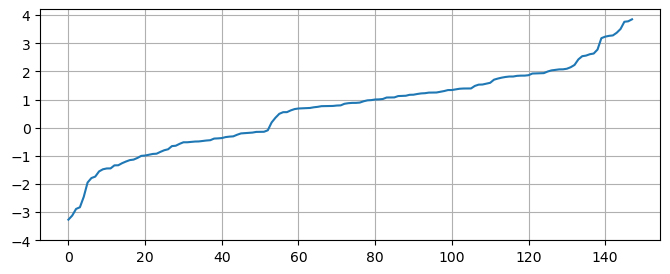

In [9]:
model = trials.model("Diag")
in_file = os.path.join(model.base_dir, "in.27.p")
assert os.path.exists(in_file), f"Input file {in_file} does not exist"
in_params = pickle.load(open(in_file, "rb"))
in_params["data_file"] = in_params["data_file"].replace("/camp/home/tootoos/working/tootoos/git", os.environ["GIT"])
in_params["sampler"]["n_train"] = 10 
in_params["min_args"]["options"]["gtol"]= 1e-8
res, dataset, mdl = driver.run(in_params, return_dataset=True, return_model=True)
plot(sorted(mdl.r)); grid(True); gca().set_yticks(arange(-4, 5, 1))

In [17]:
Q = mdl.compute_quartic_coefs()
Xn = norm(Q.X, axis=1)

All Xs were the same, so mean-of-XY-pairs quartic should be the same as fitting mean Cstar.
Q.[A|B|C|D] = Q_mean.[A|B|C|D]: OK.


In [19]:
from numpy.lib.scimath import sqrt as csqrt
xn       = norm(mdl.Xs[0],axis=1)
XU       = Q.X/xn[:,None]
mu       = Q.mi_ / (Q.mi_.shape[0] -1)
mu_n     = mu / norm(mu, axis=1)[:, None]
c        = sum(XU * mu, axis=1)
cos_th_i = sum(XU * mu_n, axis=1)
th_i     = arccos(cos_th_i)
K = 2 * csqrt(-Q.g_/3)
u = -4 * Q.h_ / K**3

In [89]:
fits = {}

# W-responses

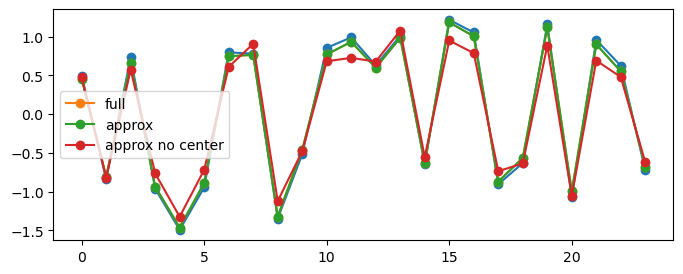

In [33]:
zz = Q.z * xn
ss = sqrt(np.abs(Q.g_)) * xn * sign(-Q.h_)
plot(zz[in_W], "o-")
fits["W"] = {
    "full": ss.copy(),
    "approx": -sign(Q.h_)* sqrt(np.abs(Q.g_)) * xn 
}
plot(c[in_W] + fits["W"]["full"][in_W], "o-", label="full")
plot(c[in_W] + fits["W"]["approx"][in_W], "o-", label="approx")
plot(fits["W"]["approx"][in_W], "o-", label="approx no center")
legend()

# J-responses

/tmp/ipykernel_1415495/1272023691.py:1: RuntimeWarning: invalid value encountered in arccosh
  ss = (cosh(1/3*arccosh(abs(u)))) * K * xn * sign(-Q.h_)
/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


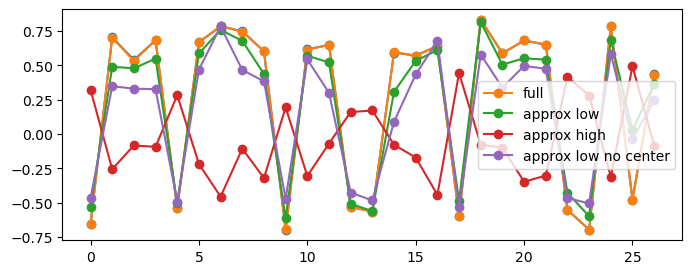

In [92]:
ss = (cosh(1/3*arccosh(abs(u)))) * K * xn * sign(-Q.h_)
plot(zz[in_J], "o-")
fits["J"] = {"full": ss, 
             "approx_low": 2/sqrt(3) * sign(-Q.h_) * sqrt(np.abs(Q.g_)) * xn,
             "approx_high": -sign(-Q.h_) * (np.abs(Q.h_) / 2)**(1/3) * xn,
}
fits["J"]["approx"] = fits["J"]["approx_low"].copy()
plot(c[in_J] + fits["J"]["full"][in_J], "o-", label="full")
plot(c[in_J] + fits["J"]["approx_low"][in_J], "o-", label="approx low")
plot(c[in_J] + fits["J"]["approx_high"][in_J], "o-", label="approx high")
plot(fits["J"]["approx_low"][in_J], "o-", label="approx low no center")
legend()

# U-responses

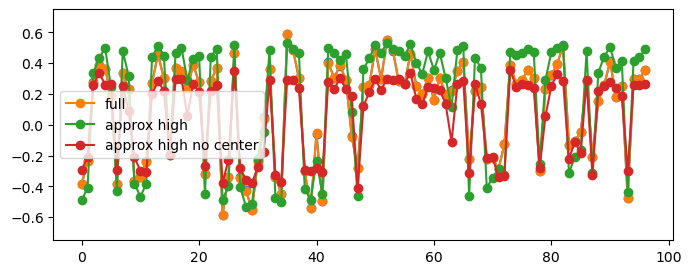

In [93]:
ss = imag(K) * sinh(1/3*arcsinh(imag(u))) * xn
plot(zz[in_U], "o-")
fits["U"] = {"full": ss,
             "approx_low": -sign(Q.h_) * (np.abs(Q.h_) / np.abs(Q.g_)) * xn,
             "approx_high": -sign(Q.h_) * (np.abs(Q.h_) / 2)**(1/3) * xn,
}
fits["U"]["approx"] = "approx_high"

plot(c[in_U] + fits["U"]["full"][in_U], "o-", label="full")
#plot(c[in_U] + fits["U"]["approx_low"][in_U], "o-", label="approx low")
plot(c[in_U] + fits["U"]["approx_high"][in_U], "o-", label="approx high")
plot(fits["U"]["approx_high"][in_U], "o-", label="approx high no center")
#plot(c[in_U] + ss1[in_U]*xn[in_U], "o-")
ylim([-1,1])
#plot(fits["U"]["approx_low"][in_U], "o-", label="approx low no center");
ylim(-3/4,3/4)
legend()


# Plot the g-h plane

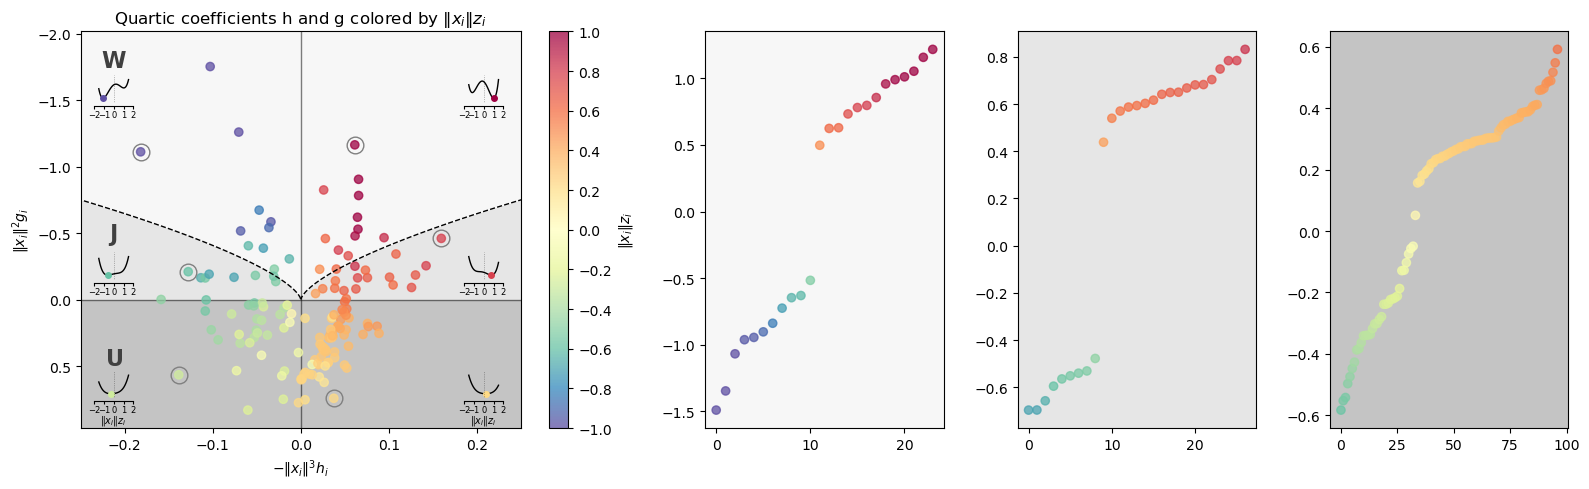

In [182]:
# Plot the phase plane: x = -|x_i|^3 h_i, y = |x_i|^2 g_i (axis inverted: negative g on top)
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 5)
figure(figsize=(16,5))
ax1 = subplot(gs[0,:2])
zz = Q.z * Xn
color_by_dict = {"$z-1$":(Q.z-1, -5, 5, "seismic"),
            "$z$":(Q.z, -4, 4, "Spectral_r"),
            "$\\|x_i\\|z_i$":(zz, -1,1, "Spectral_r"),
            "$k$":(Q.C_, -0.25, 0.25, "coolwarm"),
            "$|z|$":(np.abs(Q.z), 0, 5, "viridis"),
            "$s$": (np.sign(Q.z), -1, 1, "bwr")
}
which_scheme = "$\\|x_i\\|z_i$"
color_by = color_by_dict[which_scheme]
gg =  Q.g_.copy() * Xn**(2*1)
hh = -Q.h_.copy() * Xn**(3*1)
xx_pl = hh    # x-axis: -|x_i|^3 h_i
yy_pl = gg    # y-axis: |x_i|^2 g_i, plotted decreasing upward (inverted below)
pts = scatter(xx_pl, yy_pl, c = color_by[0], alpha=0.75, cmap=color_by[3], vmin=color_by[1], vmax=color_by[2])
#grid(True, linestyle=":")
axhline(0, zorder=-1, lw=1, color="k", alpha=0.5, ls="-")
axvline(0, zorder=-1, lw=1, color="k", alpha=0.5, ls="-")
ii = np.argsort(Q.z)
in_W = (gg < 0) & (hh**2 < (4/27) * np.abs(gg)**3)
in_J = (gg < 0) & (~in_W)
in_U = (gg > 0)
# Region backgrounds: grayscale ramp, darker where the point colors are lighter
# (U: light teal/green points on darker gray -> W: dark saturated points on near-white).
# Neutral accents so no hue competes with the gain colormap.
region_shades = {"U": "0.77", "J": "0.90", "W": "0.97"}
LABEL_COLOR   = "0.25"
INSET_COLOR   = "0.2"
# One exemplar per region per side of the tilt axis (L: h-tilt left, R: h-tilt right).
# Pick extreme points so the region shapes and tilts are clearly visible:
#   W: deep in the wedge (very negative g) with visible tilt -> clearly separated, asymmetric wells
#   J: strongest tilt (large |x|) -> single well with a pronounced shoulder
#   U: deepest bowl (large positive g) with visible tilt -> unmistakably convex
TILT_WEIGHT = 4   # |x| units are ~4x smaller than g units; balances the combined scores
extreme_score = {
    "W": lambda i: -yy_pl[i] + TILT_WEIGHT * np.abs(xx_pl[i]),
    "J": lambda i: np.abs(xx_pl[i]),
    "U": lambda i: yy_pl[i] + TILT_WEIGHT * np.abs(xx_pl[i]),
}
exemplars = {}
for name, mask, which_ord in [("U", in_U, {"L":-1,"R":-1}), ("J", in_J, {"L":-2,"R":-1}), ("W", in_W, {"L":-2,"R":-1})]:
    for side, smask in [("L", mask & (xx_pl < 0)), ("R", mask & (xx_pl > 0))]:
        idx = where(smask)[0]
        ord = argsort(extreme_score[name](idx))
        if len(idx): exemplars[(name, side)] = idx[ord[which_ord[side]]]
for (name, side), wi in exemplars.items():
    plot(xx_pl[wi], yy_pl[wi], "o", color="gray", markerfacecolor="none", markersize=12,)
xlabel("$-\|x_i\|^3 h_i$"); ylabel("$\|x_i\|^2 g_i$"); title(f"Quartic coefficients h and g colored by {which_scheme}")

#cbar_ax = ax1.inset_axes([1.02, 0, 0.03, 1])
#cb = colorbar(cax=cbar_ax, label=which_scheme)
cb = colorbar(label=which_scheme)
# Set the colorbar ticks to be [-1, 0, 1]
cb.set_ticks(np.arange(-1,1.1,0.2))

ax1.set_xlim(-0.25, 0.25)
ax1.invert_yaxis()   # negative g (double-well side) on top
# Cusp curve: 27 h^2 = 4 (-g)^3, i.e. x = +/- sqrt(4/27 (-y)^3) for y <= 0
yvals = np.linspace(min(ylim()), 0, 100)
cusp_x = np.sqrt(4/27 * (-yvals)**3)
plot(cusp_x, yvals, "k--", lw=1, label="Cusp curve"); plot(-cusp_x, yvals, "k--", lw=1);# legend(loc="lower right")
# Shade the U, J, W regions (data coords; axis inversion handles the orientation)
# NB: %pylab makes min/max numpy's -- pass sequences, never min(a, b)
x0, x1 = xlim(); y0, y1 = ylim()   # inverted axis: y0 (bottom edge) > y1 (top edge)
ylo, yhi = min([y0, y1]), max([y0, y1])
yv = np.linspace(ylo, 0, 200)          # negative-g side
cx = np.sqrt(4/27 * (-yv)**3)
ax1.axhspan(0, yhi, color=region_shades["U"], lw=0, zorder=-2)             # U: g > 0 (bottom half)
ax1.fill_betweenx(yv, cx, x1, color=region_shades["J"], lw=0, zorder=-2)   # J: g < 0, right of the cusp
ax1.fill_betweenx(yv, x0, -cx, color=region_shades["J"], lw=0, zorder=-2)  # J: g < 0, left of the cusp
ax1.fill_betweenx(yv, -cx, cx, color=region_shades["W"], lw=0, zorder=-2)  # W: between the cusp branches
lab_x = 0.065
label_pos = {"W": (lab_x+0.01, 0.91), "J": (lab_x+0.01, 0.475), "U": (lab_x+0.0125, 0.16)}   # axes fractions
for name, (tx, ty) in label_pos.items():
    ax1.text(tx, ty, name, color=LABEL_COLOR, transform=ax1.transAxes, ha="center", fontsize=16, fontweight="bold")
xlim(x0, x1); ylim(y0, y1)
# Insets: floating loss quartics, two exemplars per region (one per tilt side)
def add_loss_inset(i, xc, yc, color, sc=1.0, mincol=None,zmin=None, zmax=None):
    axi = ax1.inset_axes([xc - 0.09, yc, 0.18 * sc, 0.14*sc])
    zv = np.linspace(Q.z.min() if zmin is None else zmin/Xn[i], Q.z.max() if zmax is None else zmax/Xn[i], 100)
    axi.set_ymargin(0.25)
    axi.plot(zv*Xn[i], Q.LiFUN(i, zv), lw=1, color="k")
    # Use the exemplar's color for the floating quartic, but make it transparent so it doesn't compete with the region background
    mincol = "r" if mincol is None else mincol
    axi.plot(Q.z[i]*Xn[i], Q.LiFUN(i, Q.z[i]), "o", color=mincol, markersize=4)
    axi.patch.set_alpha(0)   # transparent: just a floating quartic
    [axi.spines[s].set_visible(False) for s in ["top", "right", "left"]]
    axi.set_yticks([]); axi.set_xticks(np.arange(-2, 3, 1))
    axi.set_xlabel("$\|x_i\|z_i$", fontsize=7, labelpad=-1)
    axi.spines["bottom"].set_position(("outward", 2))
    axi.tick_params(labelsize=6, length=2, pad=1)
    return axi

# Left insets share one x position, right insets another; rows set per region:
# W in the top corners, J just above the x-axis, U in the bottom corners.
inset_xc = {"L": 0.12, "R": 0.96}
f0 = (0 - y0) / (y1 - y0)              # axes-fraction height of the g = 0 line (works with inverted axis)
inset_yc = {"W": 0.82, "J": f0 + 0.05, "U": 0.075}
for (name, side), wi in exemplars.items():
    # Set mincol to be the color the the channel selected
    mincol = pts.cmap(pts.norm(color_by[0][wi]))
    axi = add_loss_inset(wi, inset_xc[side], inset_yc[name], INSET_COLOR, sc=0.5, mincol=mincol, zmin=-1.5, zmax=1.5)
    axi.axvline(0, color="k", lw=0.5, alpha=0.5, ls=":")
    if name != "U":
        axi.set_xlabel(None)
        #axi.set_xticklabels([])
        # Remove the x-spine
        # axi.spines["bottom"].set_visible(False)

axes = {"W": subplot(gs[0,2]),
        "J": subplot(gs[0,3]),
        "U": subplot(gs[0,4])}

for name in "WJU":
    ax = axes[name]
    mask = {"W": in_W, "J": in_J, "U": in_U}[name]
    zz_sub = zz[mask]
    order = np.argsort(zz_sub)
    ax.scatter(arange(len(order)), zz_sub[order], c = color_by[0][mask][order], alpha=0.75, cmap=color_by[3], vmin=color_by[1], vmax=color_by[2])
    # Match the side-panel background to the region's gray in the phase plane
    ax.set_facecolor(region_shades[name])

tight_layout()